In [27]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

In [28]:
data= pd.read_csv("ushape.csv")

In [29]:
data

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0
...,...,...,...
95,1.7000,0.5880,1.0
96,0.2190,-0.6530,1.0
97,0.9530,-0.4200,1.0
98,-1.3200,0.4230,0.0


In [30]:
# Training the model

knn = KNeighborsClassifier(n_neighbors=10)

def model_training(a_train, b_train, a_test):

  knn.fit(a_train, b_train)
  y_pred= knn.predict(a_test)
  return y_pred



In [31]:
X= data.iloc[:, :2].values
Y= data.iloc[:, -1].values

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [32]:
model_training(X_train, Y_train, X_test)

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
       1., 1., 1.])

In [33]:
X_train

array([[ 0.195  ,  0.161  ],
       [ 1.68   , -0.202  ],
       [ 0.606  ,  0.313  ],
       [-0.876  ,  0.0466 ],
       [ 2.18   , -0.7    ],
       [-0.367  ,  1.12   ],
       [ 1.52   , -0.0452 ],
       [ 0.219  , -0.653  ],
       [ 1.72   ,  0.361  ],
       [-0.882  ,  0.0725 ],
       [ 2.     , -0.309  ],
       [-0.369  ,  0.729  ],
       [ 0.0249 ,  0.107  ],
       [ 1.92   ,  0.172  ],
       [ 1.38   , -0.809  ],
       [ 2.11   ,  0.662  ],
       [-0.148  ,  0.962  ],
       [ 1.09   , -0.368  ],
       [-0.173  ,  1.     ],
       [ 0.301  ,  1.23   ],
       [ 0.775  ,  0.154  ],
       [ 0.0687 ,  0.566  ],
       [ 0.952  , -0.753  ],
       [ 1.7    ,  0.588  ],
       [ 2.18   , -0.0229 ],
       [ 1.16   ,  0.553  ],
       [-0.562  ,  1.05   ],
       [-0.747  , -0.383  ],
       [ 0.207  , -0.0977 ],
       [ 1.23   ,  1.2    ],
       [-0.658  , -0.129  ],
       [-0.0551 , -0.0373 ],
       [ 0.304  ,  0.824  ],
       [-0.255  ,  0.193  ],
       [-0.029

## Plotting Decision Boundary


### Creating a meshgrid

In [34]:


a= np.arange(X_train[:,0].min()-1 , X_train[:,0].max()+1, step=0.01)
b= np.arange(X_train[:,1].min()-1 , X_train[:,1].max()+1, step=0.01)

XX, YY= np.meshgrid(a,b)


In [35]:
XX.shape

(438, 550)

In [36]:
YY.shape

(438, 550)

### Creating points for the plot

In [37]:

test_data= np.array([XX.ravel(), YY.ravel()])  # Shape: (2, 41379156)

# Since test_data has shape of (2,X) but we want input to be of(X,2)

test_data= test_data.T

#Predicting values(making it short for training it fast)
y_pred= knn.predict(test_data)



In [38]:
y_pred

array([0., 0., 0., ..., 1., 1., 1.], shape=(240900,))

In [39]:
test_data.shape

(240900, 2)

### Plotting the image


In [40]:
import matplotlib.pyplot as plt

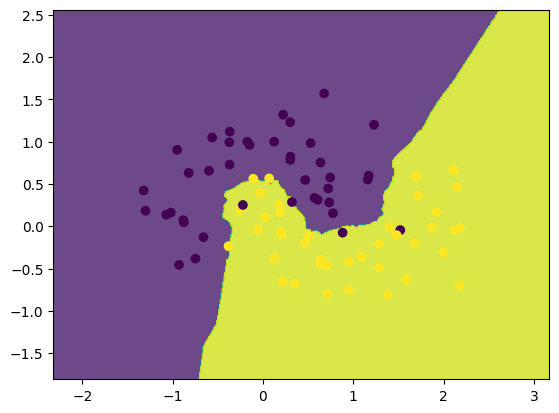

In [41]:
plt.contourf(XX,YY, y_pred.reshape(XX.shape), alpha=0.8)

# Plotting points on the graph obtained
plt.scatter(X_train[:,0],X_train[:,1], c=Y_train)